[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_5/05B-KernelsAndGaussianProcesses.ipynb)

# 05B — Kernels, Kernel Ridge Regression and Gaussian Processes

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 5, Notebook B — Hour 2**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

`05A` ended with a model that was honest about its own limits. The linear SVM scored 0.833 on the
telescope events while a random forest scored 0.935, and section 5 said why: the boundary is the
wrong *shape*, and no setting of `C` repairs a shape.

There has been a standing promise about this since Class 4. `04A` §11.2 said that the staircase a
tree builds around a curved boundary is an approximation to something else — *"a model whose
natural boundary was curved"* — and named Class 5's kernel methods as that model. This notebook
delivers it, and the mechanism is smaller than it sounds: `05A` §3.2 wrote a fitted SVM as a sum of
**dot products between samples**, and every dot product in that sum can be replaced by a different
measure of similarity. Nothing else changes. One argument in one call moves the telescope model
from the bottom of `05A`'s table to the top.

The same substitution works on ridge regression, and there it leads somewhere Class 2 could not
go. A **Gaussian process** returns the same curve as kernel ridge regression *and* an error bar on
every point of it — an uncertainty that comes from where you measured rather than from what you
measured. For an experimentalist deciding where to point an instrument next, that error bar is the
whole product.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain why a **basis expansion** rescues a curved boundary, and why choosing one by hand does
  not scale;
- state the **kernel trick** — replace every dot product by a kernel — and verify for a polynomial
  kernel that the kernel equals a dot product in an expanded space;
- say what a function must satisfy to be a valid kernel, and name the two kernels in common use;
- use the **RBF kernel**, and recognise $\gamma$ as a flexibility dial alongside `C`;
- explain why a kernel that is built from a distance makes **feature scaling** compulsory;
- write **kernel ridge regression** as the regression counterpart of the same substitution;
- state that a **Gaussian process** posterior mean *is* kernel ridge regression, and verify it;
- explain why the GP's **predictive variance does not depend on the measured values**, and use it
  to decide where to measure next;
- say what kernel methods cost as the sample size grows, and name the standard remedies.

## Where this sits in the pipeline

One step, and it is step 5.3. A kernel is a **basis expansion** — the same idea `02A` §10 used to
fit a curve with a straight-line method — except that the expansion is never built. The box is
marked *now* and, by the end of section 2, it will be the only box in the course that the model
performs on your behalf.

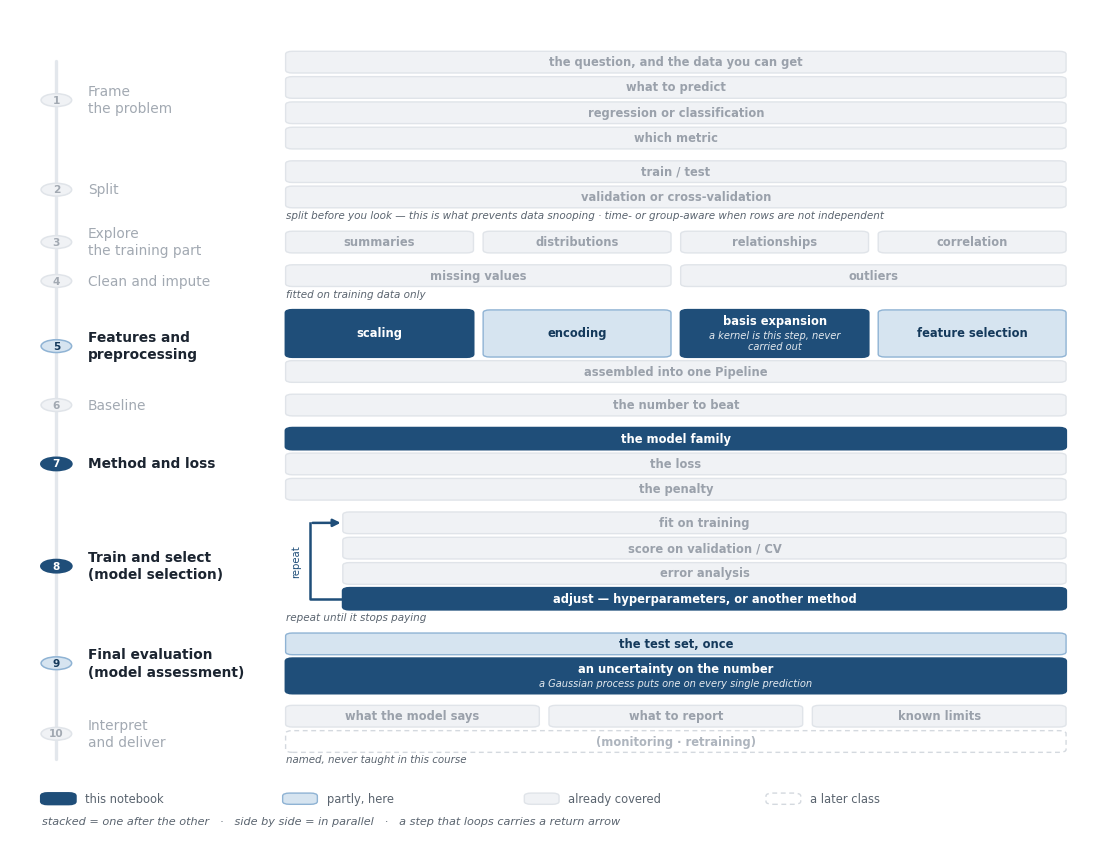

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1": "done", "2": "done", "3": "done", "4": "done", "5": "part", "5.1": "now",
     "5.3": "now", "5.after": "done", "6": "done", "7.1": "now", "7.2": "done",
     "7.3": "done", "8.1": "done", "8.2": "done", "8.3": "done", "8.4": "now",
     "9": "part", "9.2": "now", "10": "done"},
    notes={"5.3": "a kernel is this step, never carried out",
           "9.2": "a Gaussian process puts one on every single prediction"})
plt.show()

**Step 9.2 is the one to watch.** Every notebook so far has put an uncertainty on a *score* — a
fold spread, a bootstrap interval on the test RMSE. Section 5 puts one on each individual
**prediction**, which is a different object and answers a different question.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.kernel_approximation import Nystroem, RBFSampler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 11,
})

rng = np.random.default_rng(0)

# 1. The boundary that has to bend

`02B` §9 built two classes as concentric rings — one class in a central disc, the other in a ring
around it — and fitted a logistic regression to them. The result was the sharpest failure in the
course: the model did not draw a bad line, it found that **no** line helps, set both coefficients
to within a few hundredths of zero, and predicted a single class everywhere.

The rings are rebuilt below exactly as `02B` built them, and three models from earlier classes are
fitted to them. Two of them have a flat boundary and one does not.

In [ ]:
n_points = 300
radius = rng.uniform(0, 1, n_points)                    # same construction as 02B section 9
angle = rng.uniform(0, 2 * np.pi, n_points)

X_rings = np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])
y_rings = (radius < 0.5).astype(int)                    # inner disc is class 1

contenders = [("logistic regression (02B)", LogisticRegression()),
              ("linear SVM (05A)", SVC(kernel="linear")),
              ("decision tree, depth 5 (04A)", DecisionTreeClassifier(max_depth=5, random_state=0))]

print(f"{'':30}{'training accuracy':>19}")
for name, model in contenders:
    print(f"{name:30}{model.fit(X_rings, y_rings).score(X_rings, y_rings):>19.3f}")
print(f"\nmajority class alone: {max(y_rings.mean(), 1 - y_rings.mean()):.3f}")

                                training accuracy
logistic regression (02B)                   0.550
linear SVM (05A)                            0.550
decision tree, depth 5 (04A)                0.980

majority class alone: 0.550


The two flat boundaries score 0.550, which is exactly the majority class — they have learned
nothing at all. The tree reaches 0.980 by stacking axis-aligned cuts into a staircase, which is
`04A` §11.2's picture, and `04A` §11.2 promised that the staircase is an approximation to a model
whose boundary is genuinely curved.

## 1.1 The feature you can add by hand

There is an easy fix here, and it is not a new method. The rings are separated by their **distance
from the origin**: the inner class has $x_1^2 + x_2^2 < 0.25$ and the outer class does not. So add
that quantity as a third feature and fit the *same* logistic regression.

logistic regression on (x1, x2)          : 0.550
logistic regression on (x1, x2, r^2)     : 0.967
coefficients on the three features       : [-0.15  0.01 -7.39]


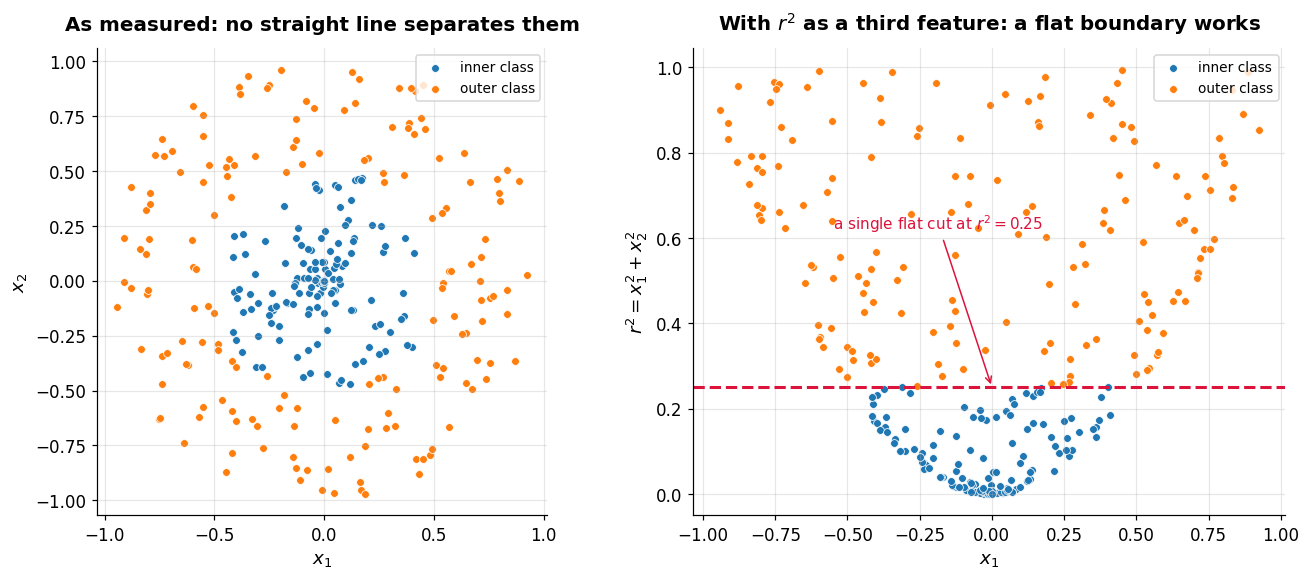

In [ ]:
X_lifted = np.column_stack([X_rings, (X_rings ** 2).sum(axis=1)])   # the new feature is r^2

lifted_model = LogisticRegression().fit(X_lifted, y_rings)
print(f"logistic regression on (x1, x2)          : {LogisticRegression().fit(X_rings, y_rings).score(X_rings, y_rings):.3f}")
print(f"logistic regression on (x1, x2, r^2)     : {lifted_model.score(X_lifted, y_rings):.3f}")
print(f"coefficients on the three features       : {lifted_model.coef_[0].round(2)}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
for value, name in [(1, "inner class"), (0, "outer class")]:
    mask = y_rings == value
    axes[0].scatter(X_rings[mask, 0], X_rings[mask, 1], s=26, edgecolor="white", linewidth=0.5, label=name)
    axes[1].scatter(X_rings[mask, 0], X_lifted[mask, 2], s=26, edgecolor="white", linewidth=0.5, label=name)
axes[0].set(xlabel="$x_1$", ylabel="$x_2$", title="As measured: no straight line separates them")
axes[0].set_aspect("equal")
axes[1].axhline(0.25, color="crimson", linestyle="--", linewidth=2)
axes[1].set(xlabel="$x_1$", ylabel="$r^2 = x_1^2 + x_2^2$",
            title="With $r^2$ as a third feature: a flat boundary works")
axes[1].annotate("a single flat cut at $r^2 = 0.25$", xy=(0.0, 0.25), xytext=(-0.55, 0.62),
                 fontsize=10, color="crimson",
                 arrowprops={"arrowstyle": "->", "color": "crimson"})
for axis in axes:
    axis.legend(loc="upper right", fontsize=9)
plt.show()

Accuracy moves from 0.550 to 0.967 with no change of method. This is the **basis expansion** of
`02A` §10 — step 5.3 of the map — and the right-hand panel shows why it works: in the new
coordinate the two classes sit one above the other, and a flat boundary is all that is needed.

**And there is the catch.** It worked because the rings were drawn on a page and the useful
feature was visible. On the telescope data of `05A` there are ten features, the useful expansion
might involve products of any of them, and nobody can look at a ten-dimensional scatter plot. The
number of degree-2 products of $p$ features is $p(p+1)/2$, so ten features give 55 of them and a
hundred features give 5050 — and degree 3 is worse. Building the expansion is a dead end.

> A basis expansion is not a trick for curved data; it is the *only* way a flat-boundary method
> ever fits a curve. The question is never whether to expand, but who chooses the expansion and
> who pays for it.

# 2. The kernel trick

## 2.1 The expansion you never compute

Here is the observation the rest of the notebook rests on. `05A` §3.2 showed that a fitted SVM can
be written as a sum over its support vectors, in which the samples appear **only inside dot
products**. *ISLR* makes the same point in its ch. 9.3.2: the solution to the support vector
classifier problem involves only the inner products of the observations, and to estimate the
coefficients *"all we need are the $\binom{n}{2}$ inner products between all pairs of training
observations"*.

So suppose we did build an expansion $\boldsymbol{\phi}(\mathbf{x})$ and fitted the SVM in the
expanded space. Every appearance of the samples would be a dot product
$\boldsymbol{\phi}(\mathbf{x}) \cdot \boldsymbol{\phi}(\mathbf{x}')$ — never
$\boldsymbol{\phi}(\mathbf{x})$ on its own. If some cheap function
$K(\mathbf{x}, \mathbf{x}')$ returned that dot product directly, the expansion would never have to
be built.

For the degree-2 polynomial expansion in two dimensions, such a function exists and it is one
line. Take

$$
\boldsymbol{\phi}(\mathbf{x}) = \big(1,\; \sqrt{2}\,x_1,\; \sqrt{2}\,x_2,\; x_1^2,\;
\sqrt{2}\,x_1 x_2,\; x_2^2\big) ,
$$

a six-dimensional vector containing every term up to degree 2. The claim is that

$$
\boldsymbol{\phi}(\mathbf{x}) \cdot \boldsymbol{\phi}(\mathbf{x}')
\;=\; \big(1 + \mathbf{x}\cdot\mathbf{x}'\big)^2 ,
$$

where the right-hand side costs one dot product in the **original** two dimensions. Rather than
take that on trust, evaluate both sides.

In [ ]:
def expansion(x):
    """Every polynomial term up to degree 2, for a sample with two features."""
    return np.array([1, np.sqrt(2) * x[0], np.sqrt(2) * x[1],
                     x[0] ** 2, np.sqrt(2) * x[0] * x[1], x[1] ** 2])

first, second = rng.normal(size=2), rng.normal(size=2)

in_six_dimensions = expansion(first) @ expansion(second)      # build it, then take the dot product
from_the_kernel = (1 + first @ second) ** 2                   # never build it

print(f"dot product of the two expansions : {in_six_dimensions:.12f}")
print(f"the kernel, in two dimensions     : {from_the_kernel:.12f}")
print(f"difference                        : {abs(in_six_dimensions - from_the_kernel):.1e}")

dot product of the two expansions : 0.561618430735
the kernel, in two dimensions     : 0.561618430735
difference                        : 1.1e-16


They agree to machine precision. The six-dimensional expansion was built on the left and never
built on the right, and the two numbers are the same.

That is the **kernel trick**: wherever a method uses samples only through dot products, replacing
each dot product $\mathbf{x}\cdot\mathbf{x}'$ by a kernel $K(\mathbf{x}, \mathbf{x}')$ fits the
method in an expanded space at the cost of the original one. *ESL* ch. 5.8 states the general
version — for a penalised fit of this kind the solution always takes the form
$f(\mathbf{x}) = \sum_{i=1}^{N} \alpha_i K(\mathbf{x}, \mathbf{x}_i)$ (eq. 5.50, after Wahba,
1990) — and remarks that this reduction of an infinite-dimensional problem to a finite one is
*"dubbed the kernel property in the literature on support-vector machines"*.

It is worth being clear that none of this belongs to the SVM. *ISLR* asks the question directly
in its ch. 9.5 — *"Is the SVM unique in its use of kernels to enlarge the feature space to
accommodate non-linear class boundaries?"* — and answers *"no"*, noting that logistic regression
and many other methods could use non-linear kernels too, and that their association with SVMs is
*"for historical reasons"*. Section 4 takes the trick to ridge regression for exactly this reason.

## 2.2 What is allowed to be a kernel

Not every two-argument function works. The requirement is that $K$ must be **symmetric and
positive semi-definite**: for any finite set of points, the matrix $K_{ij} = K(\mathbf{x}_i,
\mathbf{x}_j)$ must have no negative eigenvalues. *PRML* ch. 6.2 is the standard treatment, and it
gives the reason: exactly those functions can be written as a dot product in *some* feature space,
which is what the previous section needed. Functions failing it do not correspond to any expansion,
and the optimisation loses the convexity `05A` §3.4 relied on.

In practice you almost never check this, because you almost always pick one of two kernels that
*ISLR* names (ch. 9.3.2, eq. 9.22 and 9.24):

| kernel | formula | what it expands into |
|---|---|---|
| **polynomial**, degree $d$ | $(1 + \mathbf{x}\cdot\mathbf{x}')^d$ | all products of features up to degree $d$ — finite |
| **radial basis function (RBF)** | $\exp(-\gamma\lVert \mathbf{x}-\mathbf{x}'\rVert^2)$ | infinitely many dimensions |

## 2.3 The RBF kernel is a similarity built from `05A`'s distance

The RBF kernel is the one in general use, and it should look familiar: inside it is the squared
Euclidean distance that the whole of `05A` §1 was about. It turns that distance into a
**similarity** — 1 when two samples coincide, falling smoothly to 0 as they separate.

$\gamma$ sets how fast it falls, and therefore how far a training sample's influence reaches.

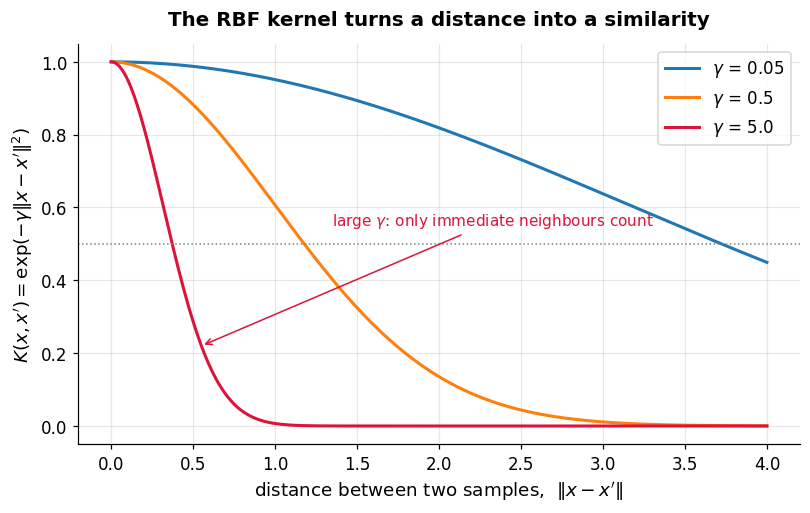

In [ ]:
separation = np.linspace(0, 4, 400)

plt.figure(figsize=(7.5, 4.8))
for gamma_value, colour in zip([0.05, 0.5, 5.0], ["tab:blue", "tab:orange", "crimson"]):
    plt.plot(separation, np.exp(-gamma_value * separation ** 2), color=colour, linewidth=2,
             label=f"$\\gamma$ = {gamma_value}")
plt.axhline(0.5, color="0.5", linestyle=":", linewidth=1)
plt.annotate("large $\\gamma$: only immediate neighbours count",
             xy=(0.55, 0.22), xytext=(1.35, 0.55), fontsize=10, color="crimson",
             arrowprops={"arrowstyle": "->", "color": "crimson"})
plt.xlabel("distance between two samples,  $\\| x - x' \\|$")
plt.ylabel("$K(x, x') = \\exp(-\\gamma \\| x - x'\\|^2)$")
plt.title("The RBF kernel turns a distance into a similarity")
plt.legend()
plt.show()

Read the two extremes, because they are the two ways an RBF model fails. With $\gamma$ small the
kernel is near 1 for every pair, every sample is similar to every other, and the fit has almost no
freedom — the high-bias end. With $\gamma$ large the kernel collapses to zero except for samples
almost on top of each other, so each training point influences only its own immediate
neighbourhood — the high-variance end, and it is `05A` §2.2's $k = 1$ in another costume.

> $\gamma$ is a flexibility dial, and it is the seventh in the course after `02C`'s polynomial
> degree, `03C`'s $\alpha$, `04A`'s depth and `ccp_alpha`, `04B`'s `max_features` and `05A`'s `C`.
> An RBF SVM has **two** dials, and they interact.

# 3. The kernel SVM

## 3.1 The rings, solved

Section 1 left the rings at 0.550 for both flat-boundary models. The next cell changes one
argument — `SVC(kernel="linear")` becomes `SVC()`, whose default kernel is RBF — and changes
nothing else.

SVM, linear kernel : 0.550
SVM, RBF kernel    : 0.987
support vectors    : 68 of 300


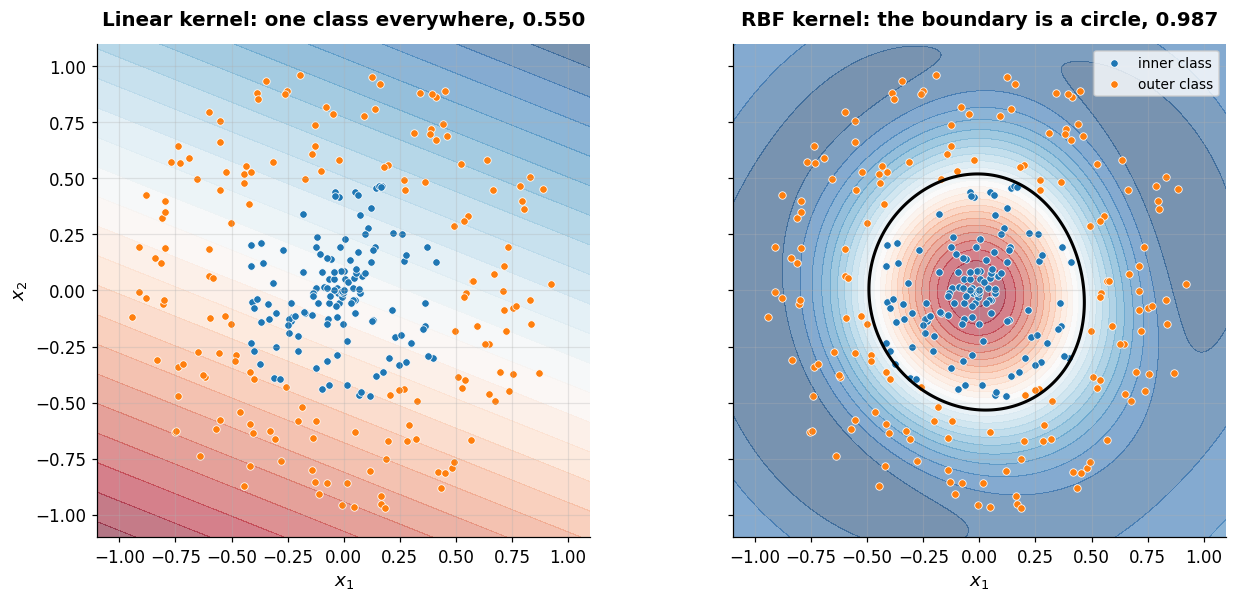

In [ ]:
rings_rbf = SVC().fit(X_rings, y_rings)                       # kernel="rbf" is the default
rings_linear = SVC(kernel="linear").fit(X_rings, y_rings)

print(f"SVM, linear kernel : {rings_linear.score(X_rings, y_rings):.3f}")
print(f"SVM, RBF kernel    : {rings_rbf.score(X_rings, y_rings):.3f}")
print(f"support vectors    : {rings_rbf.n_support_.sum()} of {n_points}")

mesh_x, mesh_y = np.meshgrid(np.linspace(-1.1, 1.1, 300), np.linspace(-1.1, 1.1, 300))
mesh = np.column_stack([mesh_x.ravel(), mesh_y.ravel()])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6), sharey=True)
for axis, model, title in [(axes[0], rings_linear, "Linear kernel: one class everywhere, 0.550"),
                           (axes[1], rings_rbf, "RBF kernel: the boundary is a circle, 0.987")]:
    scores = model.decision_function(mesh).reshape(mesh_x.shape)
    axis.contourf(mesh_x, mesh_y, scores, levels=25, cmap="RdBu_r", alpha=0.55)
    axis.contour(mesh_x, mesh_y, scores, levels=[0], colors="black", linewidths=2)
    for value, name in [(1, "inner class"), (0, "outer class")]:
        mask = y_rings == value
        axis.scatter(X_rings[mask, 0], X_rings[mask, 1], s=24, edgecolor="white",
                     linewidth=0.5, label=name)
    axis.set(xlabel="$x_1$", title=title)
    axis.set_aspect("equal")
axes[0].set_ylabel("$x_2$")
axes[1].legend(loc="upper right", fontsize=9)
plt.show()

0.987 — against 0.550 for the same machine with a flat boundary, and 0.967 for the $r^2$ feature
built by hand in section 1.1. Nobody told the model that the classes were arranged in rings, and
no expanded design matrix was ever constructed.

This is `04A` §11.2's promise discharged. The tree reached 0.980 by cutting a staircase; the RBF
SVM reaches 0.987 with a boundary that is simply round, because round is what the data are.

## 3.2 $\gamma$ and `C` are two dials, and one of them overfits fast

The next cell sweeps $\gamma$ over four orders of magnitude on 4,000 telescope events, holding
`C` fixed, and reports the training ROC AUC beside the cross-validated one.

1. Which way will the **training** score move as $\gamma$ grows?
2. Which way will the **cross-validated** score move?
3. The number of support vectors is printed too. `05A` §3.4 found that samples inside the margin
   are support vectors — so what should that count do at the two ends of the sweep?

**Think about your answer before running this cell.**

In [ ]:
magic = fetch_openml(data_id=1120, as_frame=True, parser="auto")
X_magic = magic.data.rename(columns=lambda name: name.rstrip(":"))   # OpenML's names end in ":"
y_magic = (magic.target == "g").astype(int)                          # 1 = gamma, 0 = hadron

X_train, X_test, y_train, y_test = train_test_split(X_magic, y_magic, test_size=0.25,
                                                    random_state=0, stratify=y_magic)
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

subset = slice(0, 4000)                       # a quarter of the training events, to keep this quick
print(f"{'gamma':>8}{'training ROC AUC':>19}{'cross-validated':>18}{'support vectors':>18}")
for gamma_value in [0.001, 0.01, 0.1, 1.0, 10.0]:
    machine = make_pipeline(StandardScaler(), SVC(gamma=gamma_value, C=10))
    validated = cross_val_score(machine, X_train[subset], y_train[subset], cv=folds,
                                scoring="roc_auc", n_jobs=-1)
    machine.fit(X_train[subset], y_train[subset])
    trained = roc_auc_score(y_train[subset], machine.decision_function(X_train[subset]))
    print(f"{gamma_value:>8}{trained:>19.4f}{validated.mean():>18.4f}{machine[-1].n_support_.sum():>18}")

The output, since it is not stored in the notebook: the training score climbs from 0.8535 at
$\gamma = 0.001$ to **1.0000** at $\gamma = 10$ — a perfect score on its own training events. The
cross-validated score does something quite different. It rises to 0.9105 at $\gamma = 0.1$ and
then **falls back to 0.8142**, worse than the linear SVM of `05A`. The support-vector count traces
a U: 2028 at the stiffest setting, 1376 at the best one, and 3998 at the loosest — which is every
one of the 4,000 events, each one carrying its own little bump.

This is the bias–variance picture of `03B` in its purest form, and the gap between the two columns
is the diagnosis: a training score of 1.0000 beside a cross-validated 0.8142 is a model that has
memorised. `05A`'s `C` sweep could not produce this, because a straight line has too little
freedom to memorise anything. With a kernel, the model has as much freedom as you ask for.

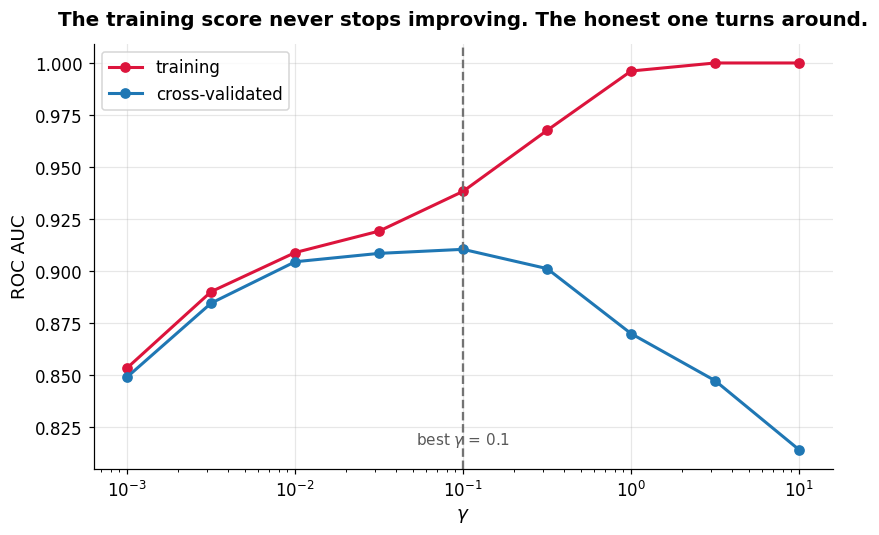

In [ ]:
gammas = np.logspace(-3, 1, 9)
train_curve, validated_curve = [], []
for gamma_value in gammas:
    machine = make_pipeline(StandardScaler(), SVC(gamma=gamma_value, C=10))
    validated_curve.append(cross_val_score(machine, X_train[subset], y_train[subset], cv=folds,
                                           scoring="roc_auc", n_jobs=-1).mean())
    machine.fit(X_train[subset], y_train[subset])
    train_curve.append(roc_auc_score(y_train[subset], machine.decision_function(X_train[subset])))

best = gammas[int(np.argmax(validated_curve))]
plt.figure(figsize=(7.8, 5))
plt.semilogx(gammas, train_curve, "o-", color="crimson", linewidth=2, label="training")
plt.semilogx(gammas, validated_curve, "o-", color="tab:blue", linewidth=2, label="cross-validated")
plt.axvline(best, color="0.45", linestyle="--", linewidth=1.5)
plt.annotate(f"best $\\gamma$ = {best:.3g}", xy=(best, min(validated_curve)), fontsize=10,
             color="0.35", ha="center", va="bottom")
plt.xlabel("$\\gamma$")
plt.ylabel("ROC AUC")
plt.title("The training score never stops improving. The honest one turns around.")
plt.legend()
plt.show()

## 3.3 Back to the telescope

`05A` §4.1 left a table with three tiers on these events: the two flat-boundary models at 0.833
and 0.837, nearest neighbours at 0.900, and the tree ensembles at about 0.935. The linear SVM was
at the bottom. Refit it on the full training set with an RBF kernel and a tuned `C`.

In [ ]:
print(f"{'':44}{'cross-validated ROC AUC':>26}")
for name, machine in [("linear SVM, C = 1 (05A section 4.1)", SVC(kernel="linear", C=1)),
                      ("RBF kernel, default C = 1", SVC()),
                      ("RBF kernel, C = 10", SVC(C=10))]:
    scores = cross_val_score(make_pipeline(StandardScaler(), machine), X_train, y_train,
                             cv=folds, scoring="roc_auc", n_jobs=-1)
    print(f"{name:44}{scores.mean():>20.4f} +/- {scores.std():.4f}")

print("\nfor reference, from 05A section 4.1:")
print(f"{'31 nearest neighbours':44}{0.900:>20.4f}")
print(f"{'random forest, 300 trees (04B)':44}{0.935:>20.4f}")

                                               cross-validated ROC AUC


linear SVM, C = 1 (05A section 4.1)                       0.8328 +/- 0.0056


RBF kernel, default C = 1                                 0.9154 +/- 0.0041


RBF kernel, C = 10                                        0.9236 +/- 0.0049

for reference, from 05A section 4.1:
31 nearest neighbours                                     0.9000
random forest, 300 trees (04B)                            0.9350


0.8328 to 0.9236. One argument, and the SVM has crossed two tiers of `05A`'s table: past nearest
neighbours at 0.900 and within 0.012 of the random forest, which is the strongest model the course
has fitted to these events. The boundary really was the problem, exactly as `05A` §5 diagnosed,
and `C` really could not fix it.

**A caution, and it is the honest half of the result.** This is the best-case advertisement for
kernels: ten continuous features on a common physical footing, 14,265 events, and a genuinely
curved boundary. Section 6 shows what the same model costs at ten times the sample size, and the
benchmark literature places the two families closer than this single table suggests — across 121
datasets, Fernández-Delgado et al. (2014) found random forests the strongest family overall, with
RBF-kernel SVMs immediately behind them.

## 3.4 A kernel built from a distance must be given scaled features

`05A` §1 showed that an unscaled Euclidean distance on these events is dominated by four
millimetre-valued features, while three others — including the total light — contribute less than
0.01% of it. The RBF kernel has that same distance inside it, so it inherits that same defect, and
`StandardScaler` is not an optional tidiness.

In [ ]:
for label, machine in [("RBF kernel, raw features", SVC(C=10)),
                       ("RBF kernel, inside a StandardScaler", make_pipeline(StandardScaler(), SVC(C=10)))]:
    scores = cross_val_score(machine, X_train, y_train, cv=folds, scoring="roc_auc", n_jobs=-1)
    print(f"{label:38}{scores.mean():>10.4f} +/- {scores.std():.4f}")

RBF kernel, raw features                  0.8835 +/- 0.0047


RBF kernel, inside a StandardScaler       0.9236 +/- 0.0049


0.8835 unscaled against 0.9236 scaled — four hundredths of ROC AUC thrown away by a missing step,
with no error and no warning. It is `05A` §1's lesson again, and the reason it has to be repeated
is that the kernel hides the distance: nothing in `SVC(C=10)` looks like it is measuring one.

> Any method with a distance inside it needs its features scaled, and a kernel is a distance in
> disguise. The scaler goes inside the pipeline, so that each fold's scaling is fitted on that
> fold's training part only — `02C` §6.3.

# 4. The same substitution, for regression

Nothing in section 2 was about classification. The kernel trick applies to any method that touches
its samples only through dot products, and ridge regression from `03C` is such a method: *ESL*
ch. 5.8 gives the general penalised solution as $f(\mathbf{x}) = \sum_i \alpha_i K(\mathbf{x},
\mathbf{x}_i)$ with the coefficients solving a finite problem in $\boldsymbol{\alpha}$ (eq. 5.50
and 5.52). Making that substitution in ridge regression gives **kernel ridge regression**, and
scikit-learn spells it `KernelRidge`.

**The physics.** `02A` fitted a spring, and a spring is the harmonic approximation to something
that is not harmonic. The potential energy of a real diatomic molecule as a function of the
distance between the two nuclei is a **Morse curve**: steeply repulsive when the nuclei are pushed
together, a minimum at the bond length, and flattening to a constant as the bond breaks.

Each point on such a curve costs a separate quantum-chemistry calculation, so in practice a curve
is known at a handful of geometries and wanted everywhere. The cell below takes a hydrogen-like
molecule, computes twelve points — eight around the minimum and four out in the dissociated tail —
and leaves a deliberate gap between them, which is what happens when a calculation fails to
converge across a region.

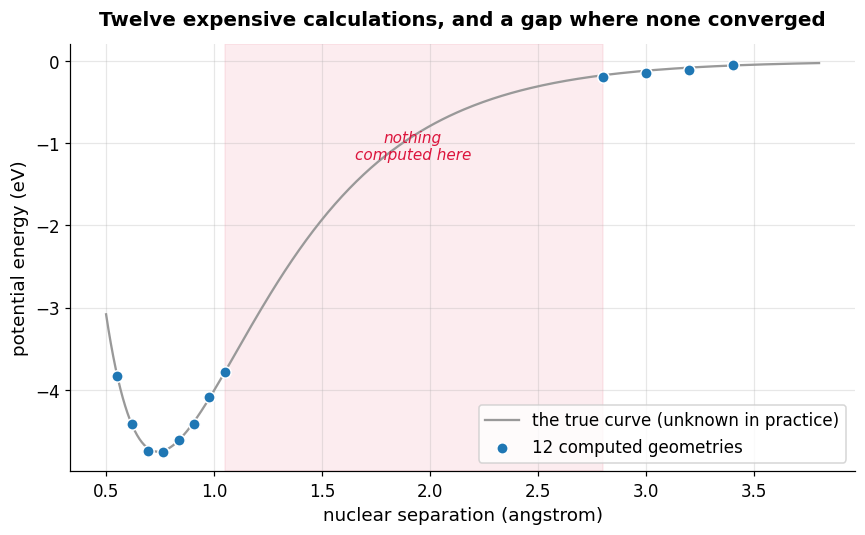

In [ ]:
well_depth, bond_length, steepness = 4.75, 0.74, 1.94       # eV and angstrom, hydrogen-like

def morse(separation):
    """Morse potential energy, in eV, for a nuclear separation in angstrom."""
    return well_depth * (1 - np.exp(-steepness * (separation - bond_length))) ** 2 - well_depth

computed_at = np.concatenate([np.linspace(0.55, 1.05, 8), np.linspace(2.8, 3.4, 4)])
noise_level = 0.02                                          # eV, the calculation's own convergence noise
energies = morse(computed_at) + rng.normal(0, noise_level, computed_at.size)
grid = np.linspace(0.5, 3.8, 300)[:, None]

plt.figure(figsize=(8, 5))
plt.plot(grid, morse(grid.ravel()), color="0.6", linewidth=1.5, label="the true curve (unknown in practice)")
plt.scatter(computed_at, energies, s=55, color="tab:blue", zorder=3, edgecolor="white",
            label="12 computed geometries")
plt.axvspan(1.05, 2.8, color="crimson", alpha=0.08)
plt.text(1.92, -1.2, "nothing\ncomputed here", ha="center", fontsize=10, color="crimson", style="italic")
plt.xlabel("nuclear separation (angstrom)")
plt.ylabel("potential energy (eV)")
plt.title("Twelve expensive calculations, and a gap where none converged")
plt.legend(loc="lower right")
plt.show()

The grey curve is drawn only so that the figures can be read; in a real calculation it is exactly
what is not known. Twelve points, a gap, and a question: what is the energy at a separation of
1.5 angstrom?

true well depth            :   4.750 eV
deepest point of the fit   :  -4.774 eV

RMSE where points were computed :   0.048 eV
RMSE inside the gap             :   0.398 eV


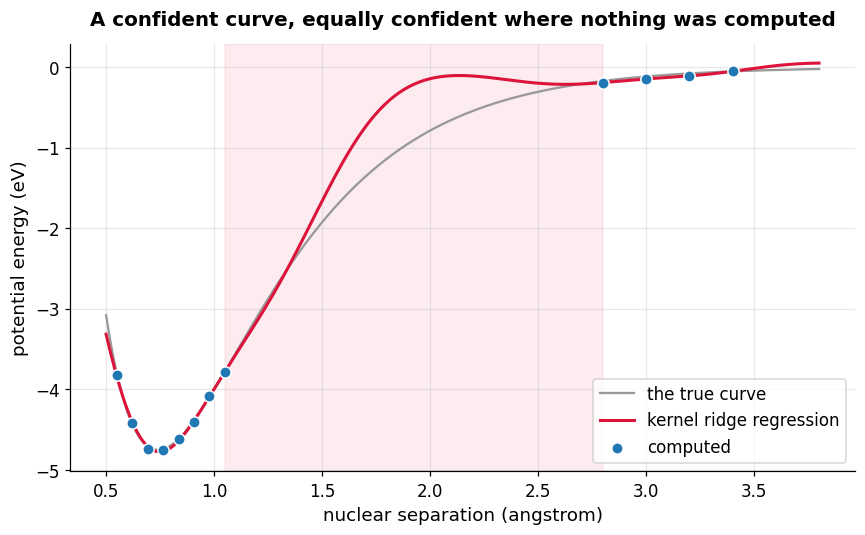

In [ ]:
length_scale = 0.35                                    # angstrom: how far the fit lets a point speak
ridge_penalty = noise_level ** 2

kernel_ridge = KernelRidge(alpha=ridge_penalty, kernel="rbf",
                           gamma=1 / (2 * length_scale ** 2)).fit(computed_at[:, None], energies)
fitted = kernel_ridge.predict(grid)

separations = grid.ravel()
truth = morse(separations)
sampled = separations < 1.1                       # where the eight calculations are
inside_gap = (separations > 1.1) & (separations < 2.8)

def rmse(where):
    """Root mean squared error of the fit against the true curve, over a region of the grid."""
    return np.sqrt(np.mean((fitted[where] - truth[where]) ** 2))

print(f"true well depth            : {-morse(bond_length):>7.3f} eV")
print(f"deepest point of the fit   : {fitted.min():>7.3f} eV")
print(f"\nRMSE where points were computed : {rmse(sampled):>7.3f} eV")
print(f"RMSE inside the gap             : {rmse(inside_gap):>7.3f} eV")

plt.figure(figsize=(8, 5))
plt.plot(grid, morse(grid.ravel()), color="0.6", linewidth=1.5, label="the true curve")
plt.plot(grid, fitted, color="crimson", linewidth=2, label="kernel ridge regression")
plt.scatter(computed_at, energies, s=55, color="tab:blue", zorder=3, edgecolor="white",
            label="computed")
plt.axvspan(1.05, 2.8, color="crimson", alpha=0.08)
plt.xlabel("nuclear separation (angstrom)")
plt.ylabel("potential energy (eV)")
plt.title("A confident curve, equally confident where nothing was computed")
plt.legend(loc="lower right")
plt.show()

Read the two errors. Where the calculations sit, the fit tracks the true curve to 0.048 eV.
Across the gap it is out by 0.398 eV — eight times worse, and on the scale of a chemical bond
rather than of a rounding error. The reason is that the RBF kernel has no information there: a sum
of bumps centred on distant points decays towards its mean, so the curve climbs out of the well
far too early.

And **the figure gives no sign of it**. A red curve is drawn across the gap with exactly the same
confidence as across the eight points at the bottom of the well.

That is the honest complaint against every regression method in this course so far. The next
section fixes it.

# 5. Gaussian processes: the same curve, with an error bar

A **Gaussian process** starts from a different idea. Instead of fitting one function, it places a
probability distribution over functions and conditions it on the data, so that what comes back is
a distribution at every input: a mean and a variance.

*Gaussian Processes for Machine Learning* (Rasmussen & Williams, 2006) gives the two equations for
noisy observations in its ch. 2.2 — with $K$ the kernel matrix of the training inputs,
$\mathbf{k}_*$ the vector of kernel values between the test point and the training points, and
$\sigma_n^2$ the noise variance:

$$
\bar{f}_* \;=\; \mathbf{k}_*^{\top}\big(K + \sigma_n^2 I\big)^{-1}\mathbf{y} ,
\qquad\qquad
\mathbb{V}[f_*] \;=\; k(\mathbf{x}_*, \mathbf{x}_*) \;-\;
\mathbf{k}_*^{\top}\big(K + \sigma_n^2 I\big)^{-1}\mathbf{k}_*
$$

(eq. 2.25 and 2.26). Look at the first one before reading on. It is a weighted sum of kernel
values — the book writes it out as $\bar{f}(\mathbf{x}_*) = \sum_i \alpha_i k(\mathbf{x}_i,
\mathbf{x}_*)$ with $\boldsymbol{\alpha} = (K + \sigma_n^2 I)^{-1}\mathbf{y}$ (eq. 2.27), and calls
it *"one manifestation of the representer theorem"*.

## 5.1 The mean is kernel ridge regression

That is the same form as section 4, with the noise variance $\sigma_n^2$ standing exactly where
ridge regression's penalty stands. So the two should agree — not approximately, but to the
arithmetic. The cell below fits a GP with the same kernel and checks.

In [ ]:
process = GaussianProcessRegressor(kernel=RBF(length_scale=length_scale),
                                   alpha=ridge_penalty,      # sigma_n^2, where ridge puts its penalty
                                   optimizer=None).fit(computed_at[:, None], energies)
posterior_mean, posterior_sd = process.predict(grid, return_std=True)

print(f"largest difference between the GP posterior mean and kernel ridge regression: "
      f"{np.abs(posterior_mean - fitted).max():.1e} eV")

largest difference between the GP posterior mean and kernel ridge regression: 1.3e-13 eV


They are the same curve to thirteen decimal places, and that is not a numerical coincidence.
Rasmussen & Williams derive the regularised fit of section 4 in their ch. 6.2 and, on reaching
$\hat{\boldsymbol\alpha} = (K + \sigma_n^2 I)^{-1}\mathbf{y}$, remark: *"This should look very
familiar — it is exactly the form of the predictive mean obtained in eq. (2.23)."* They attribute
the correspondence to Kimeldorf and Wahba (1970).

So a Gaussian process is not a competitor to kernel ridge regression; for the mean, it *is* kernel
ridge regression, arrived at from probability rather than from a penalty. Everything section 4
fitted, it fitted too.

The second equation is what the extra machinery buys.

## 5.2 The error bar does not depend on what you measured

Read $\mathbb{V}[f_*]$ again and notice what is missing from it: there is **no $\mathbf{y}$**. The
variance is built from the kernel between the test point and the training inputs, and nothing
else. Rasmussen & Williams state it flatly (ch. 2.2, p. 18):

> the variance ... does not depend on the observed targets, but only on the inputs

This is easy to mistake for a typographical accident, so the cell below fits a second process to
the same twelve geometries with the energies **replaced by random numbers**, and compares the two
error bars.

In [ ]:
nonsense = rng.normal(0, 3, energies.size)                   # not energies at all
other_process = GaussianProcessRegressor(kernel=RBF(length_scale=length_scale),
                                         alpha=ridge_penalty,
                                         optimizer=None).fit(computed_at[:, None], nonsense)
other_mean, sd_from_nonsense = other_process.predict(grid, return_std=True)

print(f"the two predicted curves differ by up to     : {np.abs(posterior_mean - other_mean).max():>8.3f} eV")
print(f"the two sets of error bars differ by up to   : {np.abs(posterior_sd - sd_from_nonsense).max():>8.1e} eV")

the two predicted curves differ by up to     :   38.971 eV
the two sets of error bars differ by up to   :  0.0e+00 eV


Not small — **exactly zero**. The two models predict entirely different curves and report
identical uncertainty, because the uncertainty answers a different question: not *"how surprising
were the measurements?"* but *"how far is this point from the places I have measured?"*

That is a strength and a limitation in one sentence, and both matter in practice.

- It is a **strength** because the error bar is available before a single measurement is taken. You
  can plan where to put the twelve calculations by computing the variance on a grid of candidate
  geometries and never running any of them.
- It is a **limitation** because the error bar cannot notice that your model is wrong. Rasmussen &
  Williams' equation subtracts *"a (positive) term, representing the information the observations
  gives us about the function"* from the prior covariance — but the prior is your choice of kernel
  and noise level, and a confidently wrong kernel gives confidently narrow bars.

One qualification, because it is easy to over-state the result. The variance ignores $\mathbf{y}$
**at a fixed kernel**, which is what the cell above fitted (`optimizer=None` holds the length scale
where it was put). In normal use the kernel's own parameters are chosen by maximising the marginal
likelihood, which *does* depend on $\mathbf{y}$ (*GPML* eq. 2.30) — so the data re-enters through
the back door, by setting the length scale. The equation is exact; "a GP's error bars never look at
the data" is not.

## 5.3 Where to compute next

at 0.80 angstrom:  predicted  -4.727 eV   +/- 0.012 eV   (true value  -4.693 eV)
at 1.95 angstrom:  predicted  -0.191 eV   +/- 0.985 eV   (true value  -0.865 eV)
at 3.10 angstrom:  predicted  -0.129 eV   +/- 0.021 eV   (true value  -0.097 eV)


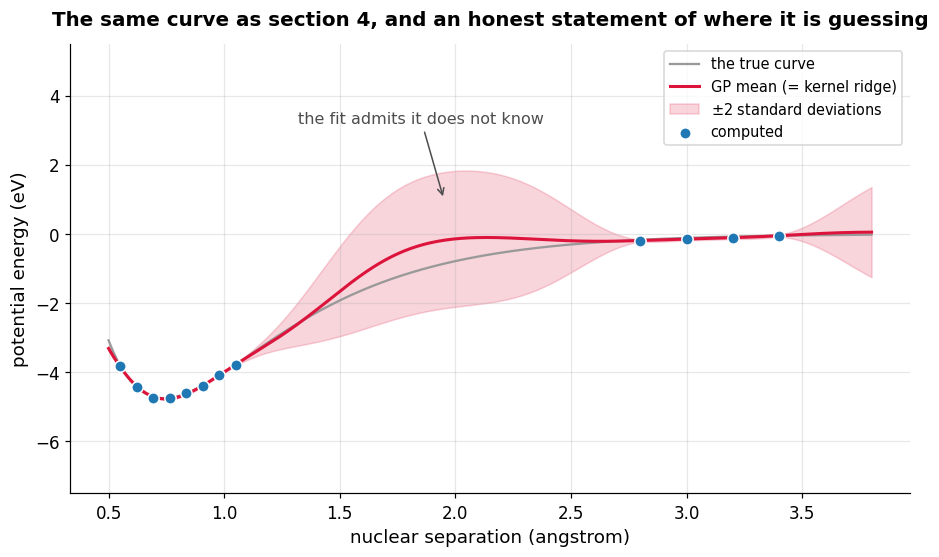

In [ ]:
for separation in [0.80, 1.95, 3.10]:
    nearest = np.abs(grid.ravel() - separation).argmin()
    print(f"at {separation:.2f} angstrom:  predicted {posterior_mean[nearest]:>7.3f} eV"
          f"   +/- {posterior_sd[nearest]:.3f} eV"
          f"   (true value {morse(separation):>7.3f} eV)")

plt.figure(figsize=(8.5, 5.2))
plt.plot(grid, morse(grid.ravel()), color="0.6", linewidth=1.5, label="the true curve")
plt.plot(grid, posterior_mean, color="crimson", linewidth=2, label="GP mean (= kernel ridge)")
plt.fill_between(grid.ravel(), posterior_mean - 2 * posterior_sd, posterior_mean + 2 * posterior_sd,
                 color="crimson", alpha=0.18, label="$\\pm 2$ standard deviations")
plt.scatter(computed_at, energies, s=55, color="tab:blue", zorder=3, edgecolor="white",
            label="computed")
plt.annotate("the fit admits it does not know", xy=(1.95, 1.0), xytext=(1.85, 3.2),
             fontsize=10.5, color="0.3", ha="center",
             arrowprops={"arrowstyle": "->", "color": "0.3"})
plt.xlabel("nuclear separation (angstrom)")
plt.ylabel("potential energy (eV)")
plt.title("The same curve as section 4, and an honest statement of where it is guessing")
plt.legend(loc="upper right", fontsize=9.5)
plt.ylim(-7.5, 5.5)
plt.show()

The error bar is 0.012 eV at 0.80 angstrom, where the calculations are packed within a tenth of an
angstrom of each other, and 0.985 eV in the middle of the gap — more than eighty times larger.
That width is doing real work: at 1.95 angstrom the fit predicts $-0.191$ eV where the truth is
$-0.865$ eV, and the $\pm 2$ standard deviation band is wide enough to contain the true curve that
section 4's red line missed in silence. Out at 3.10 angstrom, back among computed points, the bar
collapses to 0.021 eV.

That number is the product. An experimentalist with a fixed budget of measurements, or a
computational chemist with a fixed budget of CPU hours, reads the widest part of the band and puts
the next one there. Done repeatedly, that loop is **Bayesian optimisation**: the acquisition
functions that drive it are, in the words of one review, placed where *"the uncertainty in the
surrogate model is large (exploration) and/or where the model prediction is high (exploitation)"*
(Shahriari et al., 2016). This use is old and it is where Gaussian processes have always been at
home — *GPML* ch. 2.8 traces it to Sacks et al. (1989) on computer experiments and experimental
design, *"the choice of x-points that provide most information on f"*.

> A model that reports where it is ignorant is worth more than a slightly more accurate model that
> does not. This is the one place in the course where the uncertainty attaches to the individual
> prediction rather than to the score — map step 9.2.

# 6. What a kernel costs

Every equation in this notebook contains $K$, the matrix of kernel values between **every pair**
of training samples. That matrix has $n^2$ entries and the solutions invert it, so the cost grows
steeply with the sample size. `05A` §3.4 already flagged this for the SVM; the cell below measures
it.

In [ ]:
print(f"{'training events':>17}{'fit seconds':>14}")
timings = []
for size in [1000, 2000, 4000, 8000, 14265]:
    machine = make_pipeline(StandardScaler(), SVC(C=10))
    start = time.time()
    machine.fit(X_train[:size], y_train[:size])
    timings.append(time.time() - start)
    print(f"{size:>17}{timings[-1]:>14.2f}")

growth = np.log(timings[-1] / timings[0]) / np.log(14265 / 1000)
print(f"\nover this range the time grows like n^{growth:.1f}")

  training events   fit seconds
             1000          0.02


             2000          0.05
             4000          0.13


             8000          0.52


            14265          1.53

over this range the time grows like n^1.6


Fourteen times the data, and far more than fourteen times the work. The textbooks put numbers on
it. Rasmussen & Williams give the Gaussian process cost as $O(n^3)$, "due to the inversion of an
$n \times n$ matrix" (*GPML* ch. 1), and state the practical limit directly: *"For large problems
(e.g. $n > 10{,}000$) both storing the Gram matrix and solving the associated linear systems are
prohibitive on modern workstations"* (ch. 8). scikit-learn says the same of `SVC` in its own
documentation — the fit time "scales at least quadratically with the number of samples and may be
impractical beyond tens of thousands of samples". The twelve-point example of section 5 is
therefore typical of where GPs are actually used, not a toy reduction of a big problem.

The standard remedy is to approximate the kernel by an explicit, modest set of features and then
use a *linear* method on them, which is back to `05A`'s cost. scikit-learn ships two:
`Nystroem`, which builds features from a random subset of the training samples, and `RBFSampler`,
the random Fourier features of Rahimi & Recht (2007).

In [ ]:
print(f"{'':44}{'cross-validated ROC AUC':>26}")
for label, machine in [
        ("exact RBF kernel, C = 10", make_pipeline(StandardScaler(), SVC(C=10))),
        ("Nystroem, 300 features, then a linear SVM",
         make_pipeline(StandardScaler(), Nystroem(gamma=0.1, n_components=300, random_state=0),
                       LinearSVC(C=10))),
        ("RBFSampler, 300 features, then a linear SVM",
         make_pipeline(StandardScaler(), RBFSampler(gamma=0.1, n_components=300, random_state=0),
                       LinearSVC(C=10)))]:
    scores = cross_val_score(machine, X_train, y_train, cv=folds, scoring="roc_auc", n_jobs=-1)
    print(f"{label:44}{scores.mean():>20.4f} +/- {scores.std():.4f}")

                                               cross-validated ROC AUC


exact RBF kernel, C = 10                                  0.9236 +/- 0.0049


Nystroem, 300 features, then a linear SVM                 0.9241 +/- 0.0052


RBFSampler, 300 features, then a linear SVM               0.9185 +/- 0.0051


300 explicit features reproduce the exact kernel's 0.9236 — `Nystroem` at 0.9241 and `RBFSampler`
at 0.9185 — on a model whose cost is now linear in the number of events. On this dataset the
approximation costs nothing measurable; the point of the comparison is that it is available when
$n$ makes the exact kernel impossible.

# 7. The closing procedure, on a kernel SVM

The seven steps are the same as `03C` §8, `04A` §13, `04B` §12, `04C` §12 and `05A` §7, and this
time only step 4 changes: the grid has two hyperparameters in it rather than one, because section
3.2 showed that $\gamma$ and `C` both control flexibility.

In [ ]:
# 1 (map step 2) — the split made in section 3.2, before anything was looked at.
# 2 (map step 5) — a pipeline, with the scaler inside it: section 3.4.
# 3 (map step 6) — the baseline to beat is 05A's linear SVM, at 0.8328.
# 4 (map step 8) — cross-validate over BOTH dials, on the training part only.
search = GridSearchCV(make_pipeline(StandardScaler(), SVC()),
                      {"svc__gamma": [0.01, 0.1, 0.3], "svc__C": [1, 10, 100]},
                      scoring="roc_auc", cv=folds, n_jobs=-1)
search.fit(X_train, y_train)

# 5 (map step 9) — the test set, once.
test_scores = search.best_estimator_.decision_function(X_test)
test_auc = roc_auc_score(y_test, test_scores)

# 6 (map step 9.2) — an uncertainty on that number, by bootstrapping the test set.
boot = np.array([roc_auc_score(y_test.to_numpy()[idx], test_scores[idx])
                 for idx in (rng.integers(0, len(y_test), len(y_test)) for _ in range(400))])

# 7 (map step 10) — report it with its limits.
print(f"chosen gamma / C          : {search.best_params_['svc__gamma']} / {search.best_params_['svc__C']}")
print(f"cross-validated ROC AUC   : {search.best_score_:.4f}")
print(f"test ROC AUC              : {test_auc:.4f}   95% bootstrap "
      f"[{np.percentile(boot, 2.5):.4f}, {np.percentile(boot, 97.5):.4f}]")
print(f"baseline, linear SVM (05A): 0.8328")
print(f"\nthe whole grid, as cross-validation saw it:")
order = np.argsort(-search.cv_results_["mean_test_score"])
for i in order:
    p = search.cv_results_["params"][i]
    print(f"   gamma {p['svc__gamma']:<5} C {p['svc__C']:<5} "
          f"ROC AUC {search.cv_results_['mean_test_score'][i]:.4f} "
          f"+/- {search.cv_results_['std_test_score'][i]:.4f}")

chosen gamma / C          : 0.1 / 100
cross-validated ROC AUC   : 0.9246
test ROC AUC              : 0.9259   95% bootstrap [0.9175, 0.9345]
baseline, linear SVM (05A): 0.8328

the whole grid, as cross-validation saw it:
   gamma 0.1   C 100   ROC AUC 0.9246 +/- 0.0050
   gamma 0.1   C 10    ROC AUC 0.9236 +/- 0.0049
   gamma 0.3   C 10    ROC AUC 0.9199 +/- 0.0037
   gamma 0.3   C 1     ROC AUC 0.9191 +/- 0.0039
   gamma 0.1   C 1     ROC AUC 0.9154 +/- 0.0041
   gamma 0.01  C 100   ROC AUC 0.9140 +/- 0.0042
   gamma 0.3   C 100   ROC AUC 0.9108 +/- 0.0039
   gamma 0.01  C 10    ROC AUC 0.9069 +/- 0.0040
   gamma 0.01  C 1     ROC AUC 0.8949 +/- 0.0036


Read the grid, not only the winner. The scores are close across a broad region and fall away at
the corners, which is the usual shape and the reason a two-dimensional search is worth its cost
here where `05A`'s one-dimensional sweep over `C` was flat.

The reported number carries the same limits as every other in the course: it is an ROC AUC on
*these* simulated showers, from a single test split, and the bootstrap interval measures only the
test set's size — not the simulation's fidelity to a real telescope, which `05A` §6 raised and no
resampling can address.

# 8. Common pitfalls

**Leaving the features unscaled.** The RBF kernel is a distance in disguise, and section 3.4 lost
0.04 of ROC AUC to a missing `StandardScaler` with no error and no warning.

**Tuning $\gamma$ on the training score.** It rises monotonically to 1.0000 and means nothing
(section 3.2). Only the cross-validated column turns around, and it turns around well before the
training score flattens.

**Tuning $\gamma$ and `C` separately.** They both control flexibility and they interact, so a
sweep over one at a fixed value of the other can miss the good region entirely. Section 7 searches
the pair.

**Reading a kernel ridge curve as though it were supported everywhere.** Section 4 drew a
confident line through a region containing no data. Nothing in the output distinguished it from
the part of the curve that was fitted.

**Reading a Gaussian process error bar as a test of the model.** It does not depend on the
measured values at all (section 5.2), so it cannot tell you the kernel was a poor choice. It
reports distance from your measurements, nothing more.

**Reaching for an exact kernel on a large sample.** The fit grew faster than $n^2$ in section 6.
Past a few tens of thousands of samples, use `Nystroem` or `RBFSampler`, or a different family.

**Expecting a kernel to cope with irrelevant features.** This is the most firmly documented
weakness of the family, and *ESL* is blunt about it (ch. 12.3.1): *"In the early literature on
support vectors, there were claims that the kernel property ... allows one to finesse the curse of
dimensionality. Neither of these claims is true."* Its ch. 12.3.4 then measures the damage — adding
six pure-noise features to a four-feature problem moved a degree-2 polynomial SVM's error from
0.078 to 0.152, while adaptive methods barely moved (table 12.2). The reason is the one `05A` §1
gave: the kernel is a distance over *all* the features, and it cannot decide to look at a subspace.
`05A` §4.2 measured the same effect on nearest neighbours, and it is why the optional notebook `X1`
lists distance-based models as the ones for which feature selection matters most.

**Treating the kernel as a universal upgrade.** On the telescope events it bought 0.09 of ROC AUC;
the benchmark of Fernández-Delgado et al. (2014) still put random forests ahead of RBF SVMs across
121 datasets, and `04A` §11.1's advantage — a tree needs no scaling and takes mixed feature types
as they come — is untouched by any of this.

# 9. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — The degree-3 kernel</b><br>
Section 2.1 verified $\boldsymbol{\phi}(\mathbf{x}) \cdot \boldsymbol{\phi}(\mathbf{x}') = (1 + \mathbf{x}\cdot\mathbf{x}')^2$ for two features.
<br><br>
1. How many terms does a degree-3 polynomial expansion of two features have? Write them out.<br>
2. Use <code>sklearn.preprocessing.PolynomialFeatures(degree=3)</code> to build the expansion for two
random samples, and take the dot product of the results.<br>
3. Compare it with $(1 + \mathbf{x}\cdot\mathbf{x}')^3$. They will <em>not</em> be equal. Look at the
coefficients in section 2.1's <code>expansion</code> and work out what <code>PolynomialFeatures</code>
would have to multiply each term by for them to agree.<br>
4. What does this tell you about which expansion a polynomial kernel actually corresponds to?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — How far does a training point reach?</b><br>
Section 2.3 said that $\gamma$ sets the reach of each training sample.
<br><br>
1. Fit <code>SVC(gamma=g)</code> to the rings of section 1 for $g$ = 0.1, 1, 10 and 100.<br>
2. For each, draw the decision boundary over the mesh as section 3.1 does.<br>
3. Report the number of support vectors in each case, and the training accuracy.<br>
4. At $g = 100$ the training accuracy is excellent and the boundary is a collection of islands.
Explain what the model has learned, in terms of the figure in section 2.3, and say which value of
$k$ in <code>05A</code> section 2.2 it resembles.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Where would you compute next?</b><br>
Section 5.3 read the error bar off a Gaussian process fitted to twelve geometries.
<br><br>
1. Refit the process of section 5 using only the <em>eight</em> points below 1.1 angstrom.<br>
2. Plot the mean and the $\pm 2$ standard deviation band over the same grid. Where is the band
widest now?<br>
3. Add one calculation at the separation where the band is widest, refit, and report how much the
widest band has narrowed.<br>
4. Repeat step 3 twice more. Then answer: would choosing the three extra geometries on an evenly
spaced grid have done better or worse, and how would you decide that fairly?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 4 — Is the kernel worth it on your own data?</b><br>
Take any dataset from an earlier notebook with continuous features — the California housing data of
<code>04C</code> section 5, or the diabetes cohort of <code>02A</code> section 8.
<br><br>
1. Cross-validate a <code>Ridge</code> model and a <code>KernelRidge(kernel="rbf")</code> on it, both
inside a <code>StandardScaler</code>, tuning <code>alpha</code> and <code>gamma</code>.<br>
2. Record the fit time of each.<br>
3. Compare both with the gradient boosting result the earlier notebook reported.<br>
4. On the evidence of your three numbers, and of section 6's timings, when would you choose the
kernel method for this dataset? Give a condition, not a preference.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- A **basis expansion** is the only way a flat-boundary method fits a curve. Adding $r^2$ by hand
  took logistic regression from 0.550 to 0.967 on the rings — but ten features have 55 degree-2
  products and a hundred have 5050, so choosing the expansion by hand does not scale.
- The **kernel trick** replaces every dot product between samples by a kernel. For the degree-2
  polynomial kernel, $(1 + \mathbf{x}\cdot\mathbf{x}')^2$ and the dot product of two explicit
  six-dimensional expansions agree to machine precision — one of them builds the expansion and the
  other never does.
- A valid kernel is **symmetric and positive semi-definite**; those are exactly the functions that
  correspond to a dot product in some feature space (*PRML* ch. 6.2).
- The **RBF kernel** $\exp(-\gamma\lVert\mathbf{x}-\mathbf{x}'\rVert^2)$ turns `05A`'s distance
  into a similarity. On the rings it scored 0.987 against 0.550 for the same machine with a linear
  kernel, with no expansion built and nothing said about circles.
- $\gamma$ is a **flexibility dial** and it overfits hard: on 4,000 telescope events the training
  ROC AUC climbed to 1.0000 while the cross-validated score peaked at 0.9105 and fell to 0.8142.
- On the full telescope data the kernel moved the SVM from **0.8328 to 0.9236**, past nearest
  neighbours and within 0.012 of the random forest — `04A` §11.2's promise, and confirmation that
  `05A`'s diagnosis of a wrong-shaped boundary was right.
- **A kernel built from a distance needs scaled features**: 0.8835 raw against 0.9236 standardised,
  with no warning in between.
- **Kernel ridge regression** is the same substitution applied to `03C`'s ridge. On the Morse curve
  it tracked the truth to 0.048 eV where calculations existed and was out by 0.398 eV across the
  gap, with nothing in the figure to distinguish the two.
- **A Gaussian process posterior mean *is* kernel ridge regression** — the two agreed to
  $10^{-13}$ eV — with the noise variance $\sigma_n^2$ standing where the ridge penalty stands
  (*GPML* eq. 2.25).
- **The GP's error bar does not depend on the measured values.** Replacing the energies with random
  numbers changed it by exactly zero. It reports distance from your measurements: 0.012 eV among
  the computed points, 0.985 eV in the middle of the gap.
- Kernels cost $O(n^2)$ memory and up to $O(n^3)$ time. `Nystroem` with 300 features reproduced the
  exact kernel's 0.9236 at 0.9241, on a model that is linear in $n$.

# Optional preparation for the next notebook

Before `05C`, students should be comfortable with:

- the RBF kernel as a **neighbourhood**: samples within roughly $1/\sqrt{\gamma}$ of each other are
  similar, and everything beyond that is effectively invisible;
- the Euclidean distance and the need to scale before using one (`05A` §1, section 3.4 here);
- reading a two-dimensional scatter plot of labelled points, as in section 1.

`05C` keeps the distance and throws away the labels. **Clustering** asks what structure the samples
have when nothing says which class they belong to — $k$-means, hierarchical clustering, and DBSCAN,
which grows a cluster by joining samples that lie within a radius $\varepsilon$ of one another.
That $\varepsilon$-ball and this notebook's RBF kernel are the same neighbourhood idea used for two
different purposes, which is why Class 5 is one hour of supervised learning from distances followed
by one hour of unsupervised learning from the same distances.